# Factor-Specific Observability Diagnostics

This notebook extends the full calibration observability workflow with factor-specific, per-variable diagnostics. The full calibration matrix is still analyzed elsewhere; here we ask narrower questions such as: after pose and other calibration variables compensate optimally, what sensitivity remains for `T_B_L`, `T_B_I`, `b_g`, `tau_I`, or `tau_L`?


## Data Flow

The intended mathematical flow is:

`raw factor Jacobians -> whitening -> physical parameter scaling -> target/nuisance extraction -> nuisance projection -> optional column normalization -> singular values -> machine rank and effective rank -> interpretation`.

The simulation dataset returns whitened Jacobians. Physical parameter scaling expresses perturbations in meaningful characteristic units. Column normalization is only a diagnostic step for numerical rank comparison; it is not the physical information matrix used for covariance.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "calib_observability").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))

OUT = ROOT / "outputs" / "factor_observability"
OUT.mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

from calib_observability.backend import estimate_poses_dummy
from calib_observability.factor_observability import (
    SUPPORTED_CALIBRATION_VARIABLES,
    build_imu_gyro_motion_sensitivity,
    build_lidar_motion_only_matrix_dense,
    effective_rank_threshold_sweep,
    effective_target_observability_from_bundle_dense,
    effective_target_observability_from_bundle_sparse,
    sliding_window_factor_diagnostics,
)
from calib_observability.observability import reduced_information_dense
from calib_observability.simulation import PlanarRoverConfig, simulate_planar_rover


## Dataset And One-Window Jacobians

`bd.J` is the full whitened Jacobian. Its partition is `bd.J = [bd.J_T bd.J_C]`, with trajectory-pose columns first and active calibration columns second. Per-variable joint observability uses the target calibration block as `J_X` and treats trajectory plus the other calibration blocks as nuisance columns `J_N`.


In [2]:
relative_rank_threshold = 1e-5
config = PlanarRoverConfig(imu_rate_hz=40.0, lidar_rate_hz=4.0, total_laps=1, random_seed=33)
dataset = simulate_planar_rover(config, mode="one_rectangle")
pose_provider = estimate_poses_dummy(dataset)

window_start = dataset.start_time
window_end = min(dataset.start_time + 6.0, dataset.end_time)
bd, body_motions, counts = dataset.window_jacobians(window_start, window_end, pose_provider, use_sparse=False)
bs, _, _ = dataset.window_jacobians(window_start, window_end, pose_provider, use_sparse=True)

print({"J": bd.J.shape, "J_T": bd.J_T.shape, "J_C": bd.J_C.shape, "counts": counts})
print(bd.metadata.get("dimension_explanation", ""))


{'J': (207, 161), 'J_T': (207, 144), 'J_C': (207, 17), 'counts': {'imu': 23, 'lidar': 23}}
J columns = 6 * number_of_pose_nodes + number_of_active_calibration_parameters. When both IMU and LiDAR are active, the calibration vector has 17 columns: T_B_I(6), b_g(3), tau_I(1), T_B_L(6), tau_L(1). Use J_C or projected O_C for calibration-only observability analysis.


In [3]:
# Notebook-level tests: the active calibration labels must match J_C columns.
calibration_labels = list(bd.metadata["calibration_labels"])
assert len(calibration_labels) == bd.J_C.shape[1]
assert counts["imu"] > 0 and counts["lidar"] > 0
assert "T_B_I" in bd.calibration_column_slices
assert "T_B_L" in bd.calibration_column_slices


## Motion-Only Versus Joint Target Observability

`C_X_L = vstack(Adj(A_m) - I_6)` analyzes LiDAR extrinsic sensitivity with body motions treated as known. This is useful, but it ignores pose uncertainty and nuisance compensation. The joint target result `O_X = (I - J_N pinv(J_N)) J_X` answers a different question: what target sensitivity remains after nuisance variables reproduce as much of the target residual change as possible?


In [4]:
lidar_motion = build_lidar_motion_only_matrix_dense(body_motions, relative_rank_threshold=relative_rank_threshold)
imu_motion = build_imu_gyro_motion_sensitivity(bd, relative_rank_threshold=relative_rank_threshold)

target_results_dense = {}
target_results_sparse = {}
for variable_name in SUPPORTED_CALIBRATION_VARIABLES:
    if variable_name not in bd.calibration_column_slices:
        continue
    target_results_dense[variable_name] = effective_target_observability_from_bundle_dense(
        bd,
        variable_name,
        normalization="physical_then_column",
        relative_rank_threshold=relative_rank_threshold,
    )
    target_results_sparse[variable_name] = effective_target_observability_from_bundle_sparse(
        bs,
        variable_name,
        normalization="physical_then_column",
        relative_rank_threshold=relative_rank_threshold,
    )

print({"C_X_L_machine": lidar_motion.machine_rank, "C_X_L_effective": lidar_motion.effective_rank})
print({"C_R_I_machine": imu_motion.rotation_machine_rank, "C_R_I_effective": imu_motion.rotation_effective_rank})
print({name: (result.machine_rank_O_X, result.effective_rank_O_X) for name, result in target_results_dense.items()})
print(imu_motion.structural_zero_column_report)


{'C_X_L_machine': 2, 'C_X_L_effective': 2}
{'C_R_I_machine': 3, 'C_R_I_effective': 3}
{'T_B_I': (3, 3), 'T_B_L': (2, 2), 'b_g': (3, 3), 'tau_I': (1, 1), 'tau_L': (1, 1)}
{'translation_column_indices_rotation_first': [3, 4, 5], 'translation_columns_are_zero': True, 'tolerance': 1e-10, 'interpretation': 'gyro-only residuals do not depend on the translation part of T_B_I'}


In [5]:
# Dense/sparse comparison through physical projected information matrices.
# We assert on raw O_X.T @ O_X because O_X_raw is the physically meaningful
# projected matrix. Column normalization is a diagnostic transformation; for
# nearly zero projected columns it can magnify tiny LSMR residual differences.
comparison_rows = []
for variable_name, dense_result in target_results_dense.items():
    sparse_result = target_results_sparse[variable_name]
    dense_raw = np.asarray(dense_result.O_X_raw)
    sparse_raw = sparse_result.O_X_raw.toarray()
    dense_information = dense_raw.T @ dense_raw
    sparse_information = sparse_raw.T @ sparse_raw
    information_max_difference = float(np.max(np.abs(dense_information - sparse_information)))
    assert np.allclose(dense_information, sparse_information, atol=1e-5, rtol=1e-5)
    assert dense_result.machine_rank_O_X == sparse_result.machine_rank_O_X
    assert dense_result.effective_rank_O_X == sparse_result.effective_rank_O_X

    dense_normalized = np.asarray(dense_result.O_X_normalized)
    sparse_normalized = sparse_result.O_X_normalized.toarray()
    normalized_singular_difference = float(
        np.max(np.abs(dense_result.singular_values_O_X - sparse_result.singular_values_O_X))
    )
    comparison_rows.append(
        {
            "variable": variable_name,
            "raw_information_max_difference": information_max_difference,
            "normalized_singular_max_difference": normalized_singular_difference,
            "dense_normalized_rank": dense_result.effective_rank_O_X,
            "sparse_normalized_rank": sparse_result.effective_rank_O_X,
            "dense_normalized_columns": dense_normalized.shape[1],
            "sparse_normalized_columns": sparse_normalized.shape[1],
        }
    )
comparison_rows


[{'variable': 'T_B_I',
  'raw_information_max_difference': 5.374897577276649e-21,
  'normalized_singular_max_difference': 2.8270552565601292e-09,
  'dense_normalized_rank': 3,
  'sparse_normalized_rank': 3,
  'dense_normalized_columns': 6,
  'sparse_normalized_columns': 6},
 {'variable': 'T_B_L',
  'raw_information_max_difference': 8.184536292116772e-21,
  'normalized_singular_max_difference': 0.3230668087041131,
  'dense_normalized_rank': 2,
  'sparse_normalized_rank': 2,
  'dense_normalized_columns': 6,
  'sparse_normalized_columns': 6},
 {'variable': 'b_g',
  'raw_information_max_difference': 5.282943311613053e-05,
  'normalized_singular_max_difference': 4.296316635787889e-10,
  'dense_normalized_rank': 3,
  'sparse_normalized_rank': 3,
  'dense_normalized_columns': 3,
  'sparse_normalized_columns': 3},
 {'variable': 'tau_I',
  'raw_information_max_difference': 4.249825824587106e-09,
  'normalized_singular_max_difference': 2.220446049250313e-16,
  'dense_normalized_rank': 1,
  'spar

## One-Window Plots

The normalized singular values are shown as `sigma_i / sigma_max`. The horizontal line is the selected relative effective-rank threshold. Weak singular-vector coefficients describe a normalized parameter direction; signs are relative, and `v` and `-v` are the same direction. These coefficients are not parameter errors or standard deviations.


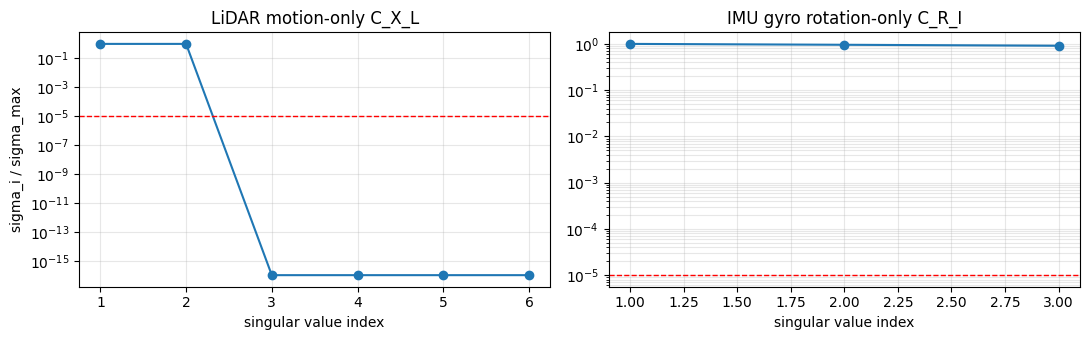

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].semilogy(np.arange(1, lidar_motion.normalized_singular_values.size + 1), np.maximum(lidar_motion.normalized_singular_values, 1e-16), marker="o")
axes[0].axhline(relative_rank_threshold, color="red", linestyle="--", linewidth=1)
axes[0].set_title("LiDAR motion-only C_X_L")
axes[0].set_xlabel("singular value index")
axes[0].set_ylabel("sigma_i / sigma_max")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(np.arange(1, imu_motion.rotation_normalized_singular_values.size + 1), np.maximum(imu_motion.rotation_normalized_singular_values, 1e-16), marker="o")
axes[1].axhline(relative_rank_threshold, color="red", linestyle="--", linewidth=1)
axes[1].set_title("IMU gyro rotation-only C_R_I")
axes[1].set_xlabel("singular value index")
axes[1].grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "motion_only_normalized_singular_values.png", dpi=160)
plt.show()
plt.close(fig)


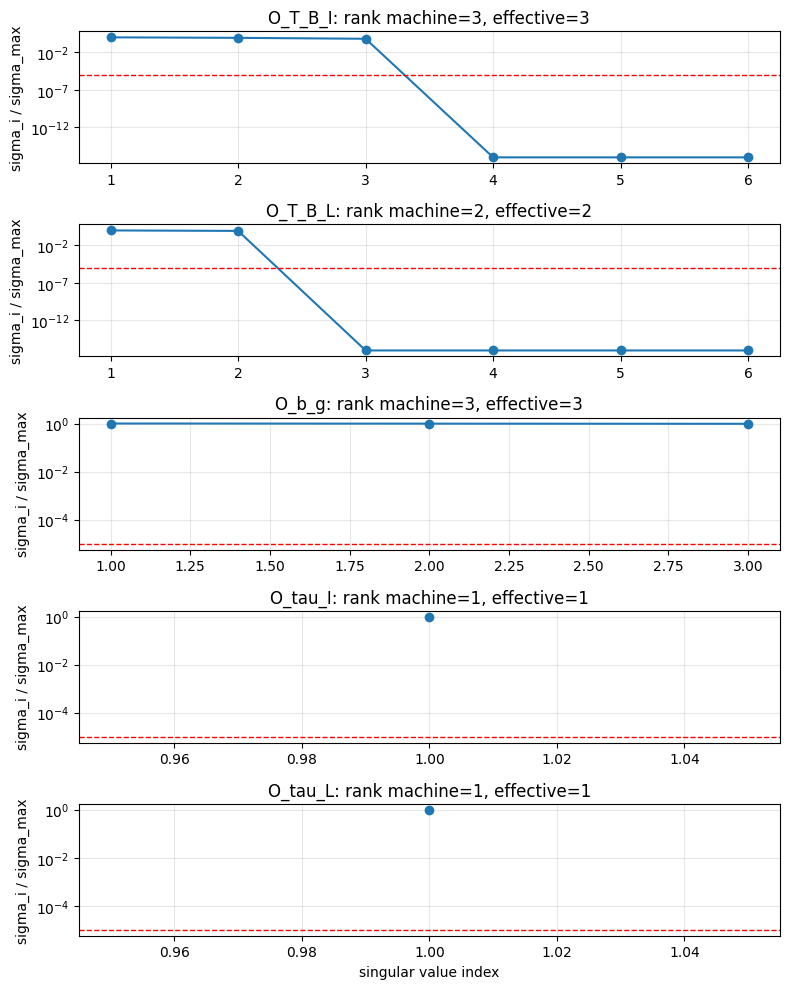

In [7]:
variable_names = list(target_results_dense)
fig, axes = plt.subplots(len(variable_names), 1, figsize=(8, max(2.2, 2.0 * len(variable_names))), sharex=False)
axes = np.atleast_1d(axes)
for ax, variable_name in zip(axes, variable_names):
    result = target_results_dense[variable_name]
    values = np.maximum(result.normalized_singular_values_O_X, 1e-16)
    ax.semilogy(np.arange(1, values.size + 1), values, marker="o")
    ax.axhline(relative_rank_threshold, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"O_{variable_name}: rank machine={result.machine_rank_O_X}, effective={result.effective_rank_O_X}")
    ax.set_ylabel("sigma_i / sigma_max")
    ax.grid(True, which="both", alpha=0.3)
axes[-1].set_xlabel("singular value index")
fig.tight_layout()
fig.savefig(OUT / "target_normalized_singular_values.png", dpi=160)
plt.show()
plt.close(fig)


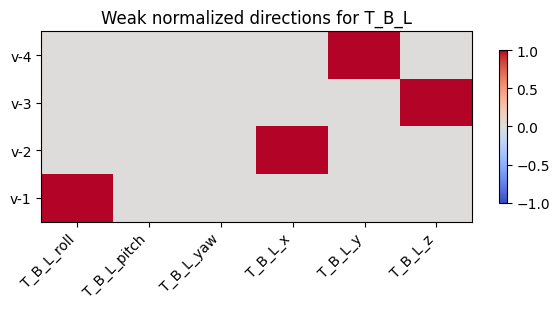

In [8]:
selected_variable = "T_B_L" if "T_B_L" in target_results_dense else variable_names[0]
selected = target_results_dense[selected_variable]
_, _, Vt = np.linalg.svd(np.asarray(selected.O_X_normalized), full_matrices=False)
weak_count = min(4, Vt.shape[0])
weak_vectors = Vt[-weak_count:]
limit = max(float(np.max(np.abs(weak_vectors))), 1e-12)

fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(selected.target_labels)), 3.2))
image = ax.imshow(weak_vectors, aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit)
ax.set_xticks(range(len(selected.target_labels)), selected.target_labels, rotation=45, ha="right")
ax.set_yticks(range(weak_count), [f"v-{index}" for index in range(weak_count, 0, -1)])
ax.set_title(f"Weak normalized directions for {selected_variable}")
fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(OUT / "weak_target_singular_vectors.png", dpi=160)
plt.show()
plt.close(fig)


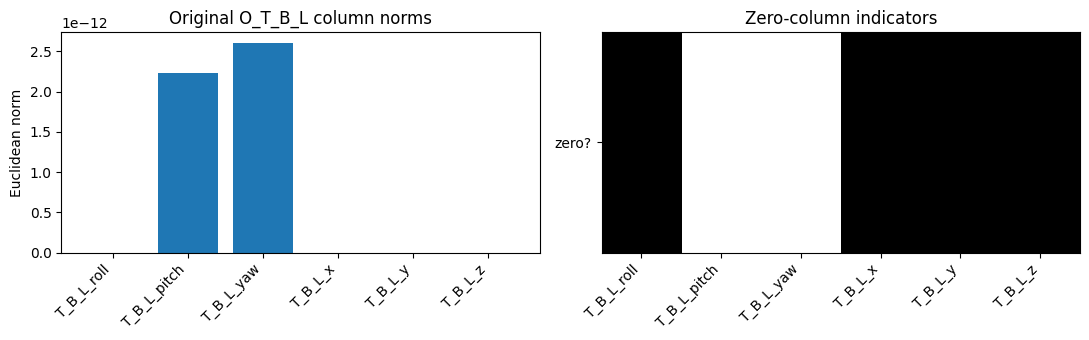

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(np.arange(len(selected.target_labels)), selected.original_target_column_norms)
axes[0].set_xticks(np.arange(len(selected.target_labels)), selected.target_labels, rotation=45, ha="right")
axes[0].set_title(f"Original O_{selected_variable} column norms")
axes[0].set_ylabel("Euclidean norm")

axes[1].imshow(selected.zero_target_column_mask[None, :], aspect="auto", cmap="gray_r", vmin=0, vmax=1)
axes[1].set_xticks(np.arange(len(selected.target_labels)), selected.target_labels, rotation=45, ha="right")
axes[1].set_yticks([0], ["zero?"])
axes[1].set_title("Zero-column indicators")
fig.tight_layout()
fig.savefig(OUT / "target_column_norms_and_zero_columns.png", dpi=160)
plt.show()
plt.close(fig)


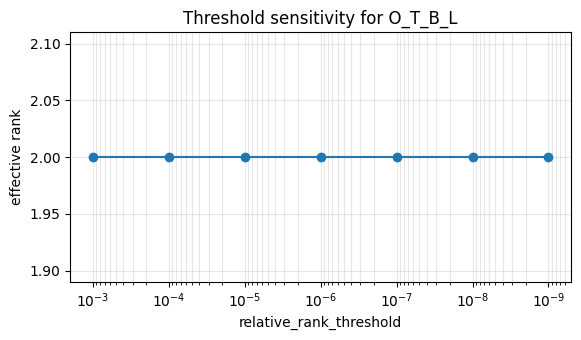

In [10]:
threshold_sweep = effective_rank_threshold_sweep(selected.singular_values_O_X)
fig, ax = plt.subplots(figsize=(6, 3.5))
thresholds = np.array(list(threshold_sweep.keys()))
ranks = np.array(list(threshold_sweep.values()))
ax.semilogx(thresholds, ranks, marker="o")
ax.invert_xaxis()
ax.set_xlabel("relative_rank_threshold")
ax.set_ylabel("effective rank")
ax.set_title(f"Threshold sensitivity for O_{selected_variable}")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "threshold_sensitivity.png", dpi=160)
plt.show()
plt.close(fig)


## Sliding-Window Diagnostics

Each window stores motion-only ranks and per-variable joint ranks separately. Effective condition number uses only singular values retained by the selected relative threshold; if fewer than two values are retained, it is reported as NaN rather than pretending to be an ordinary full condition number.


In [11]:
window_results = sliding_window_factor_diagnostics(
    dataset,
    pose_provider,
    window_duration=4.0,
    step=2.0,
    relative_rank_threshold=relative_rank_threshold,
    normalization="physical_then_column",
    use_sparse=False,
)
window_centers = np.array([0.5 * (item.window_start + item.window_end) for item in window_results])
print(f"computed {len(window_results)} windows")


computed 15 windows


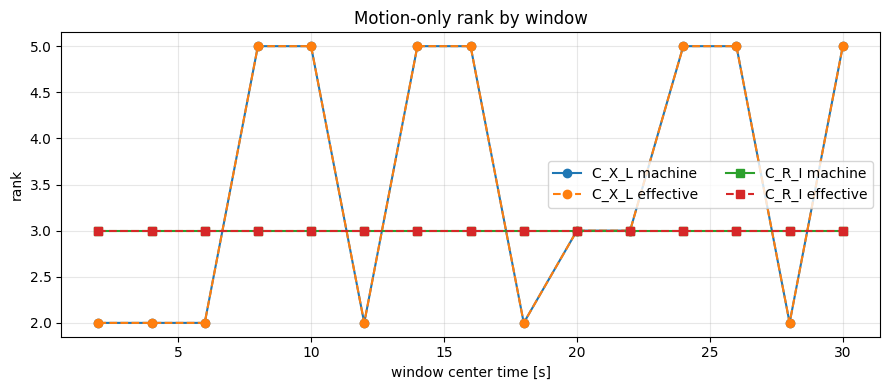

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
lidar_machine = [item.motion_lidar.machine_rank if item.motion_lidar else np.nan for item in window_results]
lidar_effective = [item.motion_lidar.effective_rank if item.motion_lidar else np.nan for item in window_results]
imu_machine = [item.motion_imu.rotation_machine_rank if item.motion_imu else np.nan for item in window_results]
imu_effective = [item.motion_imu.rotation_effective_rank if item.motion_imu else np.nan for item in window_results]
ax.plot(window_centers, lidar_machine, marker="o", label="C_X_L machine")
ax.plot(window_centers, lidar_effective, marker="o", linestyle="--", label="C_X_L effective")
ax.plot(window_centers, imu_machine, marker="s", label="C_R_I machine")
ax.plot(window_centers, imu_effective, marker="s", linestyle="--", label="C_R_I effective")
ax.set_xlabel("window center time [s]")
ax.set_ylabel("rank")
ax.set_title("Motion-only rank by window")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT / "sliding_motion_only_ranks.png", dpi=160)
plt.show()
plt.close(fig)


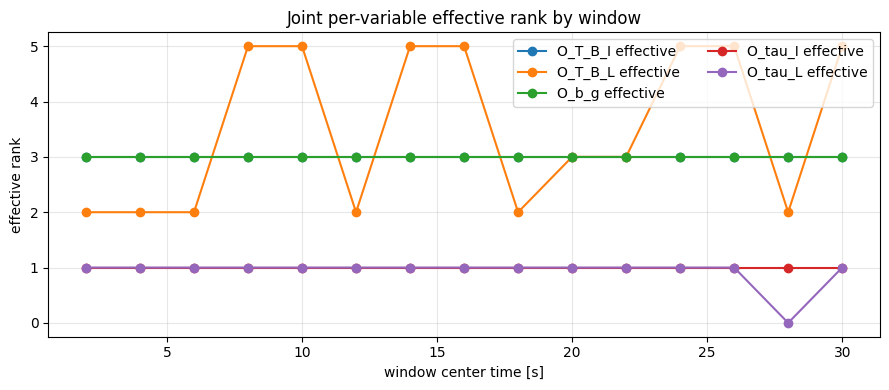

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
for variable_name in SUPPORTED_CALIBRATION_VARIABLES:
    values = [item.target_results[variable_name].effective_rank_O_X if variable_name in item.target_results else np.nan for item in window_results]
    ax.plot(window_centers, values, marker="o", label=f"O_{variable_name} effective")
ax.set_xlabel("window center time [s]")
ax.set_ylabel("effective rank")
ax.set_title("Joint per-variable effective rank by window")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT / "sliding_joint_target_effective_ranks.png", dpi=160)
plt.show()
plt.close(fig)


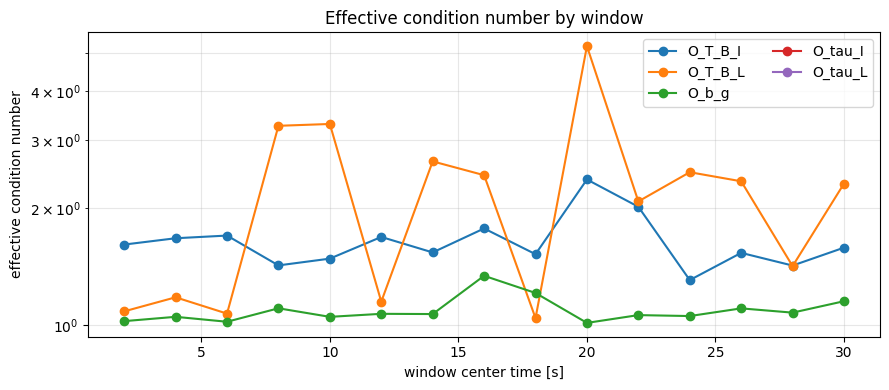

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
for variable_name in SUPPORTED_CALIBRATION_VARIABLES:
    values = [item.target_results[variable_name].effective_condition_number if variable_name in item.target_results else np.nan for item in window_results]
    ax.semilogy(window_centers, values, marker="o", label=f"O_{variable_name}")
ax.set_xlabel("window center time [s]")
ax.set_ylabel("effective condition number")
ax.set_title("Effective condition number by window")
ax.grid(True, which="both", alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT / "sliding_effective_condition_numbers.png", dpi=160)
plt.show()
plt.close(fig)


## Saved Figures

The figures are written under `outputs/factor_observability/`. Re-run the notebook after changes to the simulation or Jacobian assembly so the visual diagnostics reflect the current code.


In [15]:
print(sorted(path.name for path in OUT.glob("*.png")))


['motion_only_normalized_singular_values.png', 'sliding_effective_condition_numbers.png', 'sliding_joint_target_effective_ranks.png', 'sliding_motion_only_ranks.png', 'target_column_norms_and_zero_columns.png', 'target_normalized_singular_values.png', 'threshold_sensitivity.png', 'weak_target_singular_vectors.png']
